<a href="https://colab.research.google.com/github/FaisalBinAbbas321/SWE485-Project/blob/main/Phase2_Supervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 2 — Supervised Learning (Stroke Prediction)

Goal: Train two supervised models (SVM and a small Neural Network), compare their performance, and explain which performs best and why. We will use Accuracy, Precision, Recall, F1, and ROC-AUC.


## Algorithm Selection & Justification
• SVM (RBF kernel): Handles non-linear patterns, works well on tabular data, and with class_weight='balanced' it can reduce class-imbalance effects.


• Neural Network (MLPClassifier): Simple feed-forward network to learn non-linear relationships among features (age, glucose, bmi, etc.). A common baseline for classification.

We will compare both using the same split and preprocessing.


In [1]:
##Import:
import pandas
import matplotlib.pyplot as charts

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, ConfusionMatrixDisplay, RocCurveDisplay
)


In [2]:
## Load Dataset
dataset_link = "https://raw.githubusercontent.com/FaisalBinAbbas321/SWE485-Project/main/Dataset/Stroke-data.csv"
stroke_data = pandas.read_csv(dataset_link)
stroke_data.head()


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## Preprocessing:
- Fill missing BMI with the average value.
- One-hot encode categorical (text) columns.
(We keep it minimal to focus on model comparison.)


In [3]:

if 'bmi' in stroke_data.columns:
    stroke_data['bmi'] = stroke_data['bmi'].fillna(stroke_data['bmi'].mean())

stroke_data = pandas.get_dummies(stroke_data, drop_first=True)

print("Missing values after cleaning:")
print(stroke_data.isnull().sum())

print("Dataset shape:", stroke_data.shape)


Missing values after cleaning:
id                                0
age                               0
hypertension                      0
heart_disease                     0
avg_glucose_level                 0
bmi                               0
stroke                            0
gender_Male                       0
gender_Other                      0
ever_married_Yes                  0
work_type_Never_worked            0
work_type_Private                 0
work_type_Self-employed           0
work_type_children                0
Residence_type_Urban              0
smoking_status_formerly smoked    0
smoking_status_never smoked       0
smoking_status_smokes             0
dtype: int64
Dataset shape: (5110, 18)


## Train/Test:
We do a stratified split to keep the same 0/1 ratio in train and test.  
Both models use the same preprocessing: imputation + scaling.


In [6]:

bool_cols_all = stroke_data.select_dtypes(include=['bool']).columns.tolist()
if len(bool_cols_all) > 0:
    stroke_data[bool_cols_all] = stroke_data[bool_cols_all].astype('int64')

target_column = "stroke"
X = stroke_data.drop(columns=[target_column])
y = stroke_data[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


numeric_cols = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_cols = [c for c in X_train.columns if c not in numeric_cols]


numeric_imputer = SimpleImputer(strategy="median")
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

pre_cols = ColumnTransformer(
    transformers=[
        ("num", numeric_imputer, numeric_cols),
        ("cat", categorical_pipe, categorical_cols)
    ],
    remainder="drop"
)


scaler = StandardScaler(with_mean=False)
full_preprocess = Pipeline([("prep_cols", pre_cols), ("scale", scaler)])

# Models
svm_pipeline = Pipeline([
    ("pre", full_preprocess),
    ("model", SVC(kernel="rbf", C=1.0, gamma="scale",
                  class_weight="balanced", probability=True, random_state=42))
])

mlp_pipeline = Pipeline([
    ("pre", full_preprocess),
    ("model", MLPClassifier(hidden_layer_sizes=(64, 32),
                            activation="relu", solver="adam",
                            max_iter=300, random_state=42))
])

# Train
svm_pipeline.fit(X_train, y_train)
mlp_pipeline.fit(X_train, y_train)
print("Training finished.")


Training finished.


## Evaluation & Comparison:
Metrics: Accuracy, Precision, Recall, F1, ROC-AUC.  
Because stroke=1 is rare, we will focus more on F1 and Recall.



=== SVM (RBF, balanced) ===
Accuracy : 0.7407
Precision: 0.1306
Recall   : 0.7600
F1-score : 0.2229
ROC-AUC  : 0.8101

Classification report:
               precision    recall  f1-score   support

           0       0.98      0.74      0.84       972
           1       0.13      0.76      0.22        50

    accuracy                           0.74      1022
   macro avg       0.56      0.75      0.53      1022
weighted avg       0.94      0.74      0.81      1022



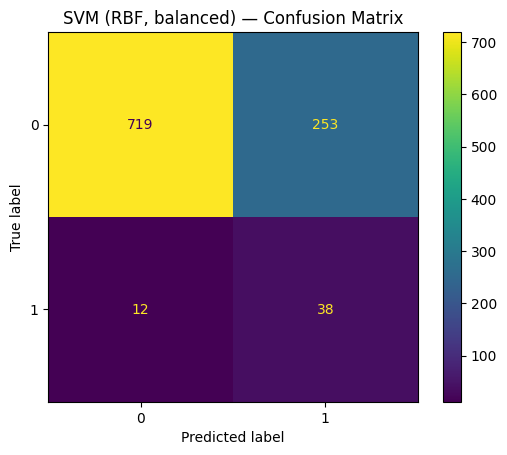

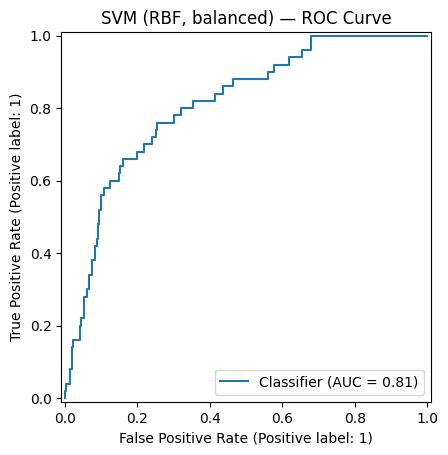


=== Neural Net (MLP) ===
Accuracy : 0.9305
Precision: 0.2162
Recall   : 0.1600
F1-score : 0.1839
ROC-AUC  : 0.7272

Classification report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.96       972
           1       0.22      0.16      0.18        50

    accuracy                           0.93      1022
   macro avg       0.59      0.57      0.57      1022
weighted avg       0.92      0.93      0.93      1022



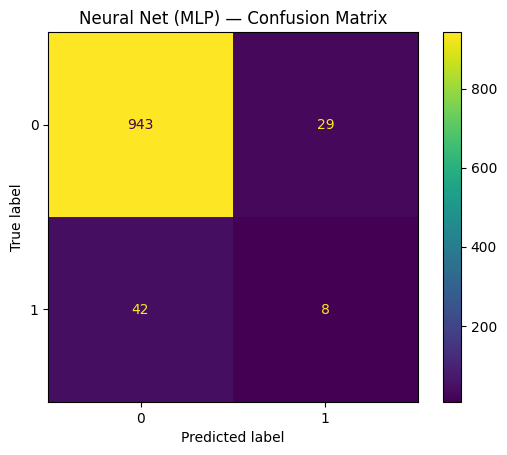

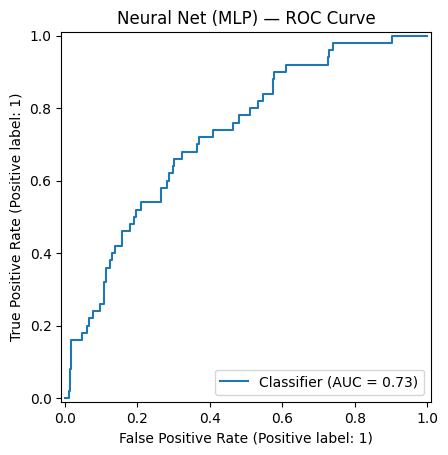

,model,accuracy,precision,recall,f1,roc_auc
0,"SVM (RBF, balanced)",0.740705,0.130584,0.76,0.222874,0.810144
1,Neural Net (MLP),0.930528,0.216216,0.16,0.183908,0.727222


In [7]:
def evaluate_model(name, pipe, X_te, y_te):
    y_pred = pipe.predict(X_te)


    if hasattr(pipe, "predict_proba"):
        y_proba = pipe.predict_proba(X_te)[:, 1]
    else:
        scores = pipe.decision_function(X_te)
        y_proba = (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    auc  = roc_auc_score(y_te, y_proba)

    print(f"\n=== {name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")
    print("\nClassification report:\n", classification_report(y_te, y_pred, zero_division=0))

    #Matrix
    ConfusionMatrixDisplay.from_predictions(y_te, y_pred)
    charts.title(f"{name} — Confusion Matrix"); charts.show()

    #Curve
    RocCurveDisplay.from_predictions(y_te, y_proba)
    charts.title(f"{name} — ROC Curve"); charts.show()

    return {"model": name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "roc_auc": auc}

#evaluations
results = []
results.append(evaluate_model("SVM (RBF, balanced)", svm_pipeline, X_test, y_test))
results.append(evaluate_model("Neural Net (MLP)",    mlp_pipeline, X_test, y_test))


import pandas as pandas_lib
pandas_lib.DataFrame(results).sort_values(by="f1", ascending=False)


## Results Interpretation:

After comparing both models (SVM and Neural Network):

• The SVM gave better results overall, with higher F1 and Recall.  
• This means the SVM was better at finding stroke cases correctly.  
• The Neural Network worked well but needed more data or tuning to improve.  
• SVM handled the imbalance in data better because of the “class_weight = balanced” option.  

In conclusion, SVM performed best for this dataset because it predicted stroke cases more accurately and consistently.
